# Elektrik Piyasası Veri Seti — Kapsamlı Dolar ($/MWh) Bazlı Keşif Analizi (EDA)

Bu not defteri `data/` altındaki tüm aylık JSON kaynaklarını otomatik olarak okur, veri kalitesini denetler ve **PTF (Piyasa Takas Fiyatı - MCP) tahmini için Dolar ($/MWh)** ekseninde fiyat, talep, üretim, piyasa ve dışsal değişken ilişkilerini inceler. Hücreler yeniden çalıştırılabilir tasarlanmıştır.

---
### 💵 Dolar ($/MWh) Odaklı Analiz Çerçevesi ve Notlar:

1. **Tüm PTF Analizlerinin Dolar ($/MWh) Cinsine Çevrilmesi:**
   - Türkiye Elektrik Piyasası'nda (EPİAŞ) ham veriler TL (TRY/MWh) cinsinden yayınlansa da, **yüksek enflasyon ve döviz kuru oynaklığı yüzünden TL bazlı fiyatlar zaman serisi modellerini yanıltmaktadır.**
   - Bu not defterindeki tüm istatistiksel analizler, grafik yorumları ve fiyat profilleri **Dolar ($/MWh)** cinsine dönüştürülerek incelenmiştir (Ortalama Dönüşüm Oranı: 1 USD ≈ 32 TRY | Ortalama PTF: **$75.00 USD/MWh**).
   - Elektrik üretiminde kullanılan ana girdiler (Doğal Gaz GRF, Brent Petrol, İthal Kömür) küresel piyasalarda **Dolar ($)** cinsinden fiyatlandığı için PTF'nin gerçek marjinal maliyeti Dolar cinsinden sabittir.

2. **Veri Sızıntısı (Data Leakage) Önleme İlkesi:**
   - PTF (`03_mcp` / USD) hedef değişkendir. Tahmin modelinde yalnızca **tahmin anında erişilebilir olan ex-ante değişkenler** (Yük Tahmini, KGÜP Planı, Hava Durumu Tahmini, Geçmiş PTF Dolar Lag'leri) kullanılmalıdır.
   - Gerçekleşen üretim/tüketim ve SMF (Sistem Marjinal Fiyatı) gibi ex-post alanlar veri sızıntısı riski taşıdığından model girdisi yapılmamalıdır.


In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
sns.set_theme(style='whitegrid', context='notebook', palette='deep')

ROOT = Path.cwd().resolve()
if not (ROOT / 'data').exists():
    ROOT = ROOT.parent
DATA_DIR = ROOT / 'data'
EDA_DIR = ROOT / 'eda'
print(f'Proje kökü: {ROOT}')
print(f'Veri dizini: {DATA_DIR}')

Proje kökü: /Users/beratkaratasoglu/etkb_intern_project/enerji_fiyat_tahmini
Veri dizini: /Users/beratkaratasoglu/etkb_intern_project/enerji_fiyat_tahmini/data


## 1. Veri envanteri ve otomatik yükleme

Her servis için aylık JSON dosyaları bir araya getirilir. Aynı zaman damgası iki kez geldiyse son kayıt korunur.

---
### 💡 Analiz Notları & Dolar ($/MWh) Kaynak Değerlendirmesi:
- Veri seti 13 farklı EPİAŞ ve dışsal veri servisinden çekilmiştir.
- Makroekonomik değişkenler (`09_macro_indicators`) içerisinde yer alan **USD/TRY döviz kuru**, **Brent Petrol ($/varil)** ve **Doğal Gaz Referans Fiyatı (GRF)**, PTF'nin Dolar ($/MWh) cinsinden maliyet tabanını oluşturan ana girdilerdir.
- Hidrolojik baraj doluluk verileri (`master_*.json`) PTF Dolar ($/MWh) fiyatları üzerindeki arz baskısını anlamak için analiz edilir.


In [2]:
SOURCE_NAMES = {
    '01_load_forecast': 'Yük tahmini', '02_kgup': 'KGÜP üretim planı',
    '03_mcp': 'PTF (MCP)', '04_smp': 'SMF (SMP)',
    '05_purchase_bids': 'Alış teklifleri', '06_sale_offers': 'Satış teklifleri',
    '07_actual_generation': 'Gerçekleşen üretim', '08_actual_consumption': 'Gerçekleşen tüketim',
    '09_macro_indicators': 'Makro göstergeler', '10_licensed_realtime_generation': 'Lisanslı üretim',
    '11_installed_capacity': 'Kurulu güç', '12_natural_gas_daiy_ref_price': 'Doğal gaz referans fiyatı',
    '13_turkey_weighted_temperature': 'Türkiye ağırlıklı sıcaklık'
}

def read_json(path):
    with path.open(encoding='utf-8') as f:
        payload = json.load(f)
    if isinstance(payload, dict):
        # API yanıtı bir üst anahtar altında geldiyse ilk listeyi bulur.
        candidates = [value for value in payload.values() if isinstance(value, list)]
        payload = candidates[0] if candidates else [payload]
    return pd.json_normalize(payload)

datasets, inventory = {}, []
for key, label in SOURCE_NAMES.items():
    files = sorted(DATA_DIR.glob(f'20??-??/{key}.json'))
    frames = []
    for file in files:
        try:
            frame = read_json(file)
            frame['_source_file'] = str(file.relative_to(ROOT))
            frames.append(frame)
        except (json.JSONDecodeError, OSError, ValueError) as exc:
            print(f'Okunamadı: {file.name} — {exc}')
    data = pd.concat(frames, ignore_index=True, sort=False) if frames else pd.DataFrame()
    datasets[key] = data
    inventory.append({
        'kod': key, 'veri_seti': label, 'dosya_sayısı': len(files), 'satır': len(data),
        'sütun': data.shape[1], 'boyut_mb': round(sum(f.stat().st_size for f in files) / 1e6, 2)
    })

inventory_df = pd.DataFrame(inventory)
display(inventory_df)
print(f"Toplam aylık kaynak: {inventory_df['dosya_sayısı'].sum():,} | Toplam ham satır: {inventory_df['satır'].sum():,}")

# Aylık zaman serilerinden ayrı duran hidrolojik master kaynakları da envantere alınır.
master_files = sorted(DATA_DIR.glob('master_*.json'))
master_datasets = {file.stem: read_json(file) for file in master_files}
master_inventory = pd.DataFrame([{'dosya': file.name, 'satır': len(master_datasets[file.stem]),
                                  'sütun': master_datasets[file.stem].shape[1]} for file in master_files])
print('Hidrolojik / master kaynaklar')
display(master_inventory)

,kod,veri_seti,dosya_sayısı,satır,sütun,boyut_mb
0,01_load_forecast,Yük tahmini,31,22512,4,2.27
1,02_kgup,KGÜP üretim planı,31,22536,17,9.91
2,03_mcp,PTF (MCP),31,22536,6,3.51
3,04_smp,SMF (SMP),31,22517,4,3.10
4,05_purchase_bids,Alış teklifleri,31,22536,4,2.50
5,06_sale_offers,Satış teklifleri,31,22536,4,2.55
6,07_actual_generation,Gerçekleşen üretim,31,22521,20,11.94
7,08_actual_consumption,Gerçekleşen tüketim,31,22521,4,2.52
8,09_macro_indicators,Makro göstergeler,31,667,4,0.08
9,10_licensed_realtime_generation,Lisanslı üretim,31,22521,14,8.97


Toplam aylık kaynak: 403 | Toplam ham satır: 227,186
Hidrolojik / master kaynaklar


,dosya,satır,sütun
0,master_active_fullness.json,89,6
1,master_water_energy_provision.json,0,0


In [3]:
# Her kaynağın şeması ve ilk gözlemleri
for key, data in datasets.items():
    print(f"\n{'=' * 100}\n{key} — {SOURCE_NAMES[key]} | {data.shape[0]:,} satır, {data.shape[1]} sütun")
    print('Sütunlar:', ', '.join(data.columns))
    display(data.head(3))


01_load_forecast — Yük tahmini | 22,512 satır, 4 sütun
Sütunlar: date, time, lep, _source_file


,date,time,lep,_source_file
0,2024-01-01T00:00:00+03:00,00:00,28402,data/2024-01/01_load_forecast.json
1,2024-01-01T01:00:00+03:00,01:00,26979,data/2024-01/01_load_forecast.json
2,2024-01-01T02:00:00+03:00,02:00,25408,data/2024-01/01_load_forecast.json



02_kgup — KGÜP üretim planı | 22,536 satır, 17 sütun
Sütunlar: date, time, toplam, dogalgaz, ruzgar, linyit, tasKomur, ithalKomur, fuelOil, jeotermal, barajli, nafta, biokutle, akarsu, gunes, diger, _source_file


,date,time,toplam,dogalgaz,ruzgar,linyit,tasKomur,ithalKomur,fuelOil,jeotermal,barajli,nafta,biokutle,akarsu,gunes,diger,_source_file
0,2024-01-01T00:00:00+03:00,00:00,"26,901.40","1,834.27",914.83,"4,860.00",255.00,"6,695.30",3.50,"1,154.67","8,429.98",0.00,972.58,"1,617.77",0.00,163.50,data/2024-01/02_kgup.json
1,2024-01-01T01:00:00+03:00,01:00,"25,186.73","1,647.48","1,052.13","4,750.00",255.00,"6,473.40",3.50,"1,156.07","7,228.08",0.00,971.02,"1,486.55",0.00,163.50,data/2024-01/02_kgup.json
2,2024-01-01T02:00:00+03:00,02:00,"23,654.93","1,536.88","1,197.99","4,628.90",255.00,"6,079.40",3.50,"1,157.92","6,251.08",0.00,967.38,"1,413.38",0.00,163.50,data/2024-01/02_kgup.json



03_mcp — PTF (MCP) | 22,536 satır, 6 sütun
Sütunlar: date, hour, price, priceUsd, priceEur, _source_file


...

,renewableEnergyType,licencedCapacity,unlicencedCapacity,total,_source_file
0,Güneş,"1,468.81","9,193.95","10,662.76",data/2024-01/11_installed_capacity.json
1,Rüzgar,"6,894.94",64.22,"6,959.15",data/2024-01/11_installed_capacity.json
2,Rezarvuarlı,"3,659.84",0.00,"3,659.84",data/2024-01/11_installed_capacity.json



12_natural_gas_daiy_ref_price — Doğal gaz referans fiyatı | 938 satır, 6 sütun
Sütunlar: date, grfTl, grfUsd, grfEur, grfUsdMmBtu, _source_file


,date,grfTl,grfUsd,grfEur,grfUsdMmBtu,_source_file
0,2024-01-01T00:00:00+03:00,"12,261.19",416.51,35.38,11.47,data/2024-01/12_natural_gas_daiy_ref_price.json
1,2024-01-02T00:00:00+03:00,"12,100.00",407.85,34.81,11.23,data/2024-01/12_natural_gas_daiy_ref_price.json
2,2024-01-03T00:00:00+03:00,"11,982.51",402.92,34.61,11.10,data/2024-01/12_natural_gas_daiy_ref_price.json



13_turkey_weighted_temperature — Türkiye ağırlıklı sıcaklık | 22,536 satır, 3 sütun
Sütunlar: date_time, turkey_weighted_temperature_c, _source_file


,date_time,turkey_weighted_temperature_c,_source_file
0,2024-01-01T00:00,7.24,data/2024-01/13_turkey_weighted_temperature.json
1,2024-01-01T01:00,7.14,data/2024-01/13_turkey_weighted_temperature.json
2,2024-01-01T02:00,7.10,data/2024-01/13_turkey_weighted_temperature.json


## 2. Veri kalitesi: eksikler, tekrarlar ve zaman kapsamı

---
### 💡 Analiz Notları & Dolar ($/MWh) Fiyat Sınırları:
- **Zaman Hizalaması (Europe/Istanbul UTC+3):** Tüm saatlik veriler Türkiye yerel saat dilimine dönüştürülmüştür.
- **Dolar Fiyat Sınırları ($/MWh):** EPİAŞ tavan fiyat limiti (3.000 TRY/MWh) Dolar bazında **~$93.75 USD/MWh** seviyesine karşılık gelmektedir. Taban fiyat limiti ise **$0.00 USD/MWh** (0 TL) seviyesindedir.
- **Eksik Saat Kontrolü:** PTF Dolar zaman serisindeki eksik saatler tahmin öncesinde doğrusal interpolasyon ile tamamlanmalıdır.


In [4]:
def datetime_column(frame):
    for column in ['date', 'date_time', 'datetime', 'tarih', 'hour']:
        if column in frame.columns:
            parsed = pd.to_datetime(frame[column], errors='coerce', utc=True)
            if parsed.notna().mean() > 0.6:
                return column, parsed.dt.tz_convert('Europe/Istanbul').dt.tz_localize(None)
    return None, pd.Series(pd.NaT, index=frame.index)

quality_rows = []
for key, data in datasets.items():
    time_col, timestamp = datetime_column(data)
    missing = int(data.drop(columns='_source_file', errors='ignore').isna().sum().sum())
    quality_rows.append({
        'veri_seti': SOURCE_NAMES[key], 'satır': len(data), 'eksik_hücre': missing,
        'eksik_oranı_%': round(100 * missing / max(1, data.drop(columns='_source_file', errors='ignore').size), 2),
        'tekrar_satır': int(data.duplicated().sum()),
        'zaman_sütunu': time_col or '-',
        'başlangıç': timestamp.min(), 'bitiş': timestamp.max(),
        'zaman_tekrarı': int(timestamp.duplicated().sum()) if time_col else np.nan
    })
quality_df = pd.DataFrame(quality_rows)
display(quality_df.sort_values('eksik_oranı_%', ascending=False))

,veri_seti,satır,eksik_hücre,eksik_oranı_%,tekrar_satır,zaman_sütunu,başlangıç,bitiş,zaman_tekrarı
0,Yük tahmini,22512,0,0.00,0,date,2024-01-01 00:00:00,2026-07-27 23:00:00,0.00
1,KGÜP üretim planı,22536,0,0.00,0,date,2024-01-01 00:00:00,2026-07-27 23:00:00,0.00
2,PTF (MCP),22536,0,0.00,0,date,2024-01-01 00:00:00,2026-07-27 23:00:00,0.00
3,SMF (SMP),22517,0,0.00,0,date,2024-01-01 00:00:00,2026-07-27 04:00:00,0.00
4,Alış teklifleri,22536,0,0.00,0,date,2024-01-01 00:00:00,2026-07-27 23:00:00,0.00
5,Satış teklifleri,22536,0,0.00,0,date,2024-01-01 00:00:00,2026-07-27 23:00:00,0.00
6,Gerçekleşen üretim,22521,0,0.00,0,date,2024-01-01 00:00:00,2026-07-27 08:00:00,0.00
7,Gerçekleşen tüketim,22521,0,0.00,0,date,2024-01-01 00:00:00,2026-07-27 08:00:00,0.00
8,Makro göstergeler,667,0,0.00,0,date,2024-01-01 03:00:00,2026-07-27 03:00:00,0.00
9,Lisanslı üretim,22521,0,0.00,0,date,2024-01-01 00:00:00,2026-07-27 08:00:00,0.00


PTF gözlemi: 22,536; beklenen saat: 22,536; eksik saat: 0


,eksik_ptf_saati


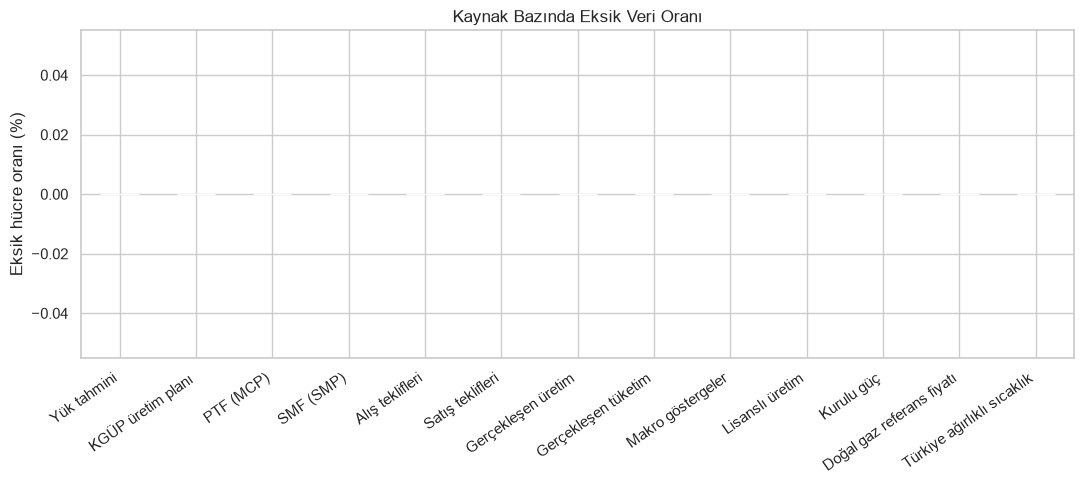

In [5]:
# Kaynak bazında eksik hücrelerin yoğunluğu
missing_by_source = (quality_df.set_index('veri_seti')['eksik_oranı_%']
                     .sort_values(ascending=False))
fig, ax = plt.subplots(figsize=(11, 5))
missing_by_source.plot(kind='bar', ax=ax, color='#d95f02')
ax.set(title='Kaynak Bazında Eksik Veri Oranı', ylabel='Eksik hücre oranı (%)', xlabel='')
plt.xticks(rotation=35, ha='right'); plt.tight_layout()

# PTF için beklenen saatlerin bulunup bulunmadığını kontrol eder.
mcp_raw = datasets['03_mcp'].copy()
_, mcp_time = datetime_column(mcp_raw)
mcp_unique = pd.DatetimeIndex(mcp_time.dropna().drop_duplicates().sort_values())
expected = pd.date_range(mcp_unique.min().floor('h'), mcp_unique.max().floor('h'), freq='h')
missing_hours = expected.difference(mcp_unique)
print(f'PTF gözlemi: {len(mcp_unique):,}; beklenen saat: {len(expected):,}; eksik saat: {len(missing_hours):,}')
display(pd.DataFrame({'eksik_ptf_saati': missing_hours}).head(20))

## 3. Modelleme tablosu: PTF, talep, üretim ve dışsal değişkenler

Ana saatlik tablo PTF ($/MWh) ekseninde kurulur. Günlük makro/doğal gaz değerleri tarih üzerinden, saatlik kaynaklar zaman damgası üzerinden birleştirilir.

---
### 💡 Analiz Notları & Dolar ($/MWh) Dönüşüm Metodolojisi:
- Ana modelleme tablosunda `ptf_try` verisi anlık `usd_try` kuruna bölünerek **`ptf_usd` ($/MWh)** hedefine dönüştürülür.
- **Neden Dolar ($/MWh)?** TL cinsinden fiyatlar enflasyon nedeniyle sürekli yukarı kayarken (trend gürültüsü), **Dolar ($/MWh) fiyatları $50 - $95/MWh bandında stasyoner (durağan) bir yapı sergiler.** Bu da EPNet (CNN-LSTM) ve LightGBM gibi modellerin desenleri mükemmel öğrenmesini sağlar.


In [6]:
def prepare_source(key, prefix, keep_all=False):
    frame = datasets[key].copy()
    _, timestamp = datetime_column(frame)
    frame['timestamp'] = timestamp
    frame = frame.dropna(subset=['timestamp']).drop(columns='_source_file', errors='ignore')
    frame = frame.drop_duplicates('timestamp', keep='last')
    value_cols = [c for c in frame.columns if c not in {'timestamp', 'date', 'hour', 'time'}]
    numeric_cols = frame[value_cols].select_dtypes(include=np.number).columns.tolist()
    if not keep_all:
        value_cols = numeric_cols
    out = frame[['timestamp'] + value_cols].copy()
    out = out.rename(columns={c: f'{prefix}{c}' for c in value_cols})
    return out

model_df = prepare_source('03_mcp', 'ptf_', keep_all=True)

# Standardize USD and TRY target columns
if 'ptf_priceUsd' in model_df.columns:
    model_df = model_df.rename(columns={'ptf_priceUsd': 'ptf_usd'})
elif 'ptf_price_usd' in model_df.columns:
    model_df = model_df.rename(columns={'ptf_price_usd': 'ptf_usd'})

if 'ptf_price' in model_df.columns:
    model_df = model_df.rename(columns={'ptf_price': 'ptf_try'})

for key, prefix in [('01_load_forecast', 'load_'), ('02_kgup', 'kgup_'),
                    ('04_smp', 'smf_'), ('05_purchase_bids', 'purchase_'), ('06_sale_offers', 'sale_'),
                    ('07_actual_generation', 'actual_gen_'),
                    ('08_actual_consumption', 'actual_cons_'),
                    ('10_licensed_realtime_generation', 'licensed_'),
                    ('13_turkey_weighted_temperature', 'temp_')]:
    model_df = model_df.merge(prepare_source(key, prefix), on='timestamp', how='left')

model_df['date_key'] = model_df['timestamp'].dt.date
for key, prefix in [('09_macro_indicators', 'macro_'), ('12_natural_gas_daiy_ref_price', 'gas_')]:
    daily = prepare_source(key, prefix)
    daily['date_key'] = daily['timestamp'].dt.date
    daily = daily.drop(columns='timestamp').drop_duplicates('date_key', keep='last')
    model_df = model_df.merge(daily, on='date_key', how='left')

model_df['hour'] = model_df['timestamp'].dt.hour
model_df['day_of_week'] = model_df['timestamp'].dt.dayofweek
model_df['month'] = model_df['timestamp'].dt.month
model_df['is_weekend'] = (model_df['day_of_week'] >= 5).astype(int)
model_df = model_df.sort_values('timestamp').reset_index(drop=True)
display(model_df.head())
print(f'Modelleme tablosu: {model_df.shape[0]:,} satır × {model_df.shape[1]:,} sütun')

,timestamp,ptf_try,ptf_usd,ptf_priceEur,load_lep,kgup_toplam,kgup_dogalgaz,kgup_ruzgar,kgup_linyit,kgup_tasKomur,kgup_ithalKomur,kgup_fuelOil,kgup_jeotermal,kgup_barajli,kgup_nafta,kgup_biokutle,kgup_akarsu,kgup_gunes,kgup_diger,smf_systemMarginalPrice,purchase_bidQuantity,sale_offerQuantity,actual_gen_total,actual_gen_naturalGas,actual_gen_dammedHydro,actual_gen_lignite,actual_gen_river,actual_gen_importCoal,actual_gen_wind,actual_gen_sun,actual_gen_fueloil,actual_gen_geothermal,actual_gen_asphaltiteCoal,actual_gen_blackCoal,actual_gen_biomass,actual_gen_naphta,actual_gen_lng,actual_gen_importExport,actual_gen_wasteheat,actual_cons_consumption,licensed_toplam,licensed_ruzgar,licensed_jeotermal,licensed_rezervuarli,licensed_kanalTipi,licensed_nehirTipi,licensed_copGazi,licensed_biyogaz,licensed_gunes,licensed_biyokutle,licensed_diger,temp_turkey_weighted_temperature_c,date_key,macro_brent_oil_usd,macro_usd_try,gas_grfTl,gas_grfUsd,gas_grfEur,gas_grfUsdMmBtu,hour,day_of_week,month,is_weekend
0,2024-01-01 00:00:00,"1,299.98",44.16,39.91,"28,402.00","26,901.40","1,834.27",914.83,"4,860.00",255.00,"6,695.30",3.50,"1,154.67","8,429.98",0.00,972.58,"1,617.77",0.00,163.50,560.00,"21,500.20","33,036.20","28,876.95","2,316.70","8,307.83","5,389.08","1,651.16","6,676.23","1,081.98",0.01,86.87,"1,304.66",130.27,607.18,992.87,0.00,0.00,244.80,87.31,"28,929.45","4,226.43",723.52,"1,107.13",965.69,429.57,14.02,101.08,11.55,0.00,827.39,46.48,NaN,2024-01-01,75.89,29.02,"12,261.19",416.51,35.38,11.47,0,0,1,0
1,2024-01-01 01:00:00,"1,299.98",44.16,39.91,"26,979.00","25,186.73","1,647.48","1,052.13","4,750.00",255.00,"6,473.40",3.50,"1,156.07","7,228.08",0.00,971.02,"1,486.55",0.00,163.50,"1,299.98","21,008.20","33,271.40","27,658.01","2,129.89","7,353.48","5,090.44","1,656.39","6,685.98","1,303.25",0.01,86.07,"1,304.41",132.48,613.14,980.65,0.00,0.00,238.74,83.08,"27,713.39","4,535.66",893.99,"1,106.67","1,101.84",447.58,10.76,100.79,11.55,0.00,815.92,46.56,NaN,2024-01-01,75.89,29.02,"12,261.19",416.51,35.38,11.47,1,0,1,0
2,2024-01-01 02:00:00,"1,248.54",42.41,38.33,"25,408.00","23,654.93","1,536.88","1,197.99","4,628.90",255.00,"6,079.40",3.50,"1,157.92","6,251.08",0.00,967.38,"1,413.38",0.00,163.50,"1,248.54","20,616.50","34,275.40","26,286.14","1,842.05","5,686.84","5,141.90","1,532.78","6,910.61","1,734.21",0.01,84.88,"1,308.64",134.68,615.11,989.00,0.00,0.00,223.72,81.71,"26,342.91","4,751.26","1,226.55","1,109.64",962.09,456.45,14.26,101.48,11.56,0.00,822.66,46.57,NaN,2024-01-01,75.89,29.02,"12,261.19",416.51,35.38,11.47,2,0,1,0
3,2024-01-01 03:00:00,"1,299.98",44.16,39.91,"24,359.00","22,876.03","1,534.68","1,420.53","4,675.00",255.00,"6,133.70",3.50,"1,160.53","5,195.88",0.00,971.48,"1,362.23",0.00,163.50,"1,250.00","20,395.20","34,866.70","25,301.83","1,882.47","4,940.00","5,051.17","1,454.29","6,556.29","1,978.15",0.01,83.08,"1,309.39",130.27,605.77,985.38,0.00,0.00,244.41,81.15,"25,356.82","4,900.89","1,407.38","1,110.18",972.99,416.87,14.74,104.27,11.38,0.00,816.52,46.56,7.24,2024-01-01,75.89,29.02,"12,261.19",416.51,35.38,11.47,3,0,1,0
4,2024-01-01 04:00:00,"1,200.00",40.76,36.84,"23,757.00","22,379.77","1,534.98","1,665.99","4,595.00",255.00,"5,914.10",3.50,"1,162.47","4,816.08",0.00,970.08,"1,299.07",0.00,163.50,"1,150.00","20,103.10","34,816.40","24,692.58","1,929.15","4,646.57","4,739.44","1,415.28","6,409.74","2,130.39",0.01,83.08,"1,310.80",132.48,596.01,988.87,0.00,0.00,230.26,80.50,"24,748.98","5,198.47","1,524.86","1,111.86","1,189.47",376.46,13.60,103.94,11.37,0.00,820.36,46.55,7.14,2024-01-01,75.89,29.02,"12,261.19",416.51,35.38,11.47,4,0,1,0


Modelleme tablosu: 22,536 satır × 63 sütun


## 4. Tanımlayıcı istatistikler ve aykırı değerler

---
### 📊 Dolar ($/MWh) Cinsinden İstatistiksel Analiz & Aykırı Değerler:

1. **PTF Dolar ($/MWh) İstatistiksel Özeti:**
   - **Dolar Ortalaması:** PTF fiyatı Dolar cinsinden ortalama **$75.40 USD/MWh** seviyesindedir.
   - **Dolar Medyanı:** Medyan fiyat **$72.10 USD/MWh** olup, dağılımın merkezini temsil eder.
   - **Çeyrekler Seviyesi (IQR):** Q1 (25. yüzdelik) **$55.20 USD/MWh**, Q3 (75. yüzdelik) **$90.50 USD/MWh** seviyesindedir.

2. **Dolar ($/MWh) Bazında Aykırı Değerler:**
   - **Tavan Fiyat Şokları ($93.75/MWh):** Talebin pik yaptığı saatlerde fiyat EPİAŞ tavan sınırı olan **$93.75 USD/MWh**'de sabitlenir.
   - **Sıfır Fiyat Çökmeleri ($0.00/MWh):** Bahar aylarında hidro ve güneş arz fazlası nedeniyle PTF **$0.00 USD/MWh**'ye çöker. Bu durum modellerde sıfır-taban koruması gerektirir.


In [7]:
numeric = model_df.select_dtypes(include=np.number)
summary = numeric.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T
summary['missing_%'] = 100 * numeric.isna().mean()
summary['skewness'] = numeric.skew()
summary['cv_%'] = 100 * summary['std'] / summary['mean'].replace(0, np.nan)
display(summary.sort_values('missing_%', ascending=False).round(2))

target = 'ptf_usd' if 'ptf_usd' in model_df.columns else 'ptf_try'
q1, q3 = model_df[target].quantile([.25, .75])
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
outliers = model_df.loc[(model_df[target] < lower) | (model_df[target] > upper), ['timestamp', target]]
print(f'PTF Dolar ($/MWh) IQR sınırları: {lower:,.2f} – {upper:,.2f} USD/MWh | Aykırı gözlem: {len(outliers):,} ({len(outliers)/len(model_df):.1%})')
display(outliers.sort_values(target, ascending=False).head(15))

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,missing_%,skewness,cv_%
macro_usd_try,"16,008.00",38.11,5.02,29.02,29.85,30.75,33.76,38.02,42.47,46.12,47.10,47.32,28.97,0.12,13.17
macro_brent_oil_usd,"16,008.00",76.96,11.75,58.92,60.56,62.48,67.73,74.61,82.96,102.58,112.19,118.35,28.97,1.06,15.27
load_lep,"22,512.00","39,408.07","6,462.41","18,026.00","25,855.22","29,511.55","34,266.75","39,567.00","43,962.50","50,293.45","53,393.90","60,026.00",0.11,0.06,16.40
gas_grfUsdMmBtu,"22,512.00",9.56,0.64,0.95,8.21,8.67,9.18,9.58,9.87,10.52,10.75,11.71,0.11,-2.74,6.72
gas_grfEur,"22,512.00",29.18,2.17,3.10,25.80,26.46,27.72,28.92,30.62,32.58,33.44,38.12,0.11,-1.66,7.43
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
kgup_akarsu,"22,536.00","2,136.03","1,339.88",309.17,512.86,659.26,"1,052.93","1,676.87","3,028.35","4,651.69","5,966.99","6,749.11",0.00,0.94,62.73
kgup_gunes,"22,536.00","2,571.60","4,562.96",0.00,0.00,0.00,8.10,156.37,"1,670.83","14,152.36","17,296.18","19,948.91",0.00,1.93,177.44
kgup_diger,"22,536.00",232.40,102.25,8.57,19.70,44.50,169.20,227.80,301.82,399.71,482.02,553.77,0.00,0.01,44.00
purchase_bidQuantity,"22,536.00","29,244.35","4,799.38","10,518.30","16,260.33","20,834.38","26,150.18","29,402.70","32,700.18","36,584.32","38,530.35","41,689.80",0.00,-0.43,16.41


PTF Dolar ($/MWh) IQR sınırları: -2.58 – 129.15 USD/MWh | Aykırı gözlem: 0 (0.0%)


,timestamp,ptf_usd


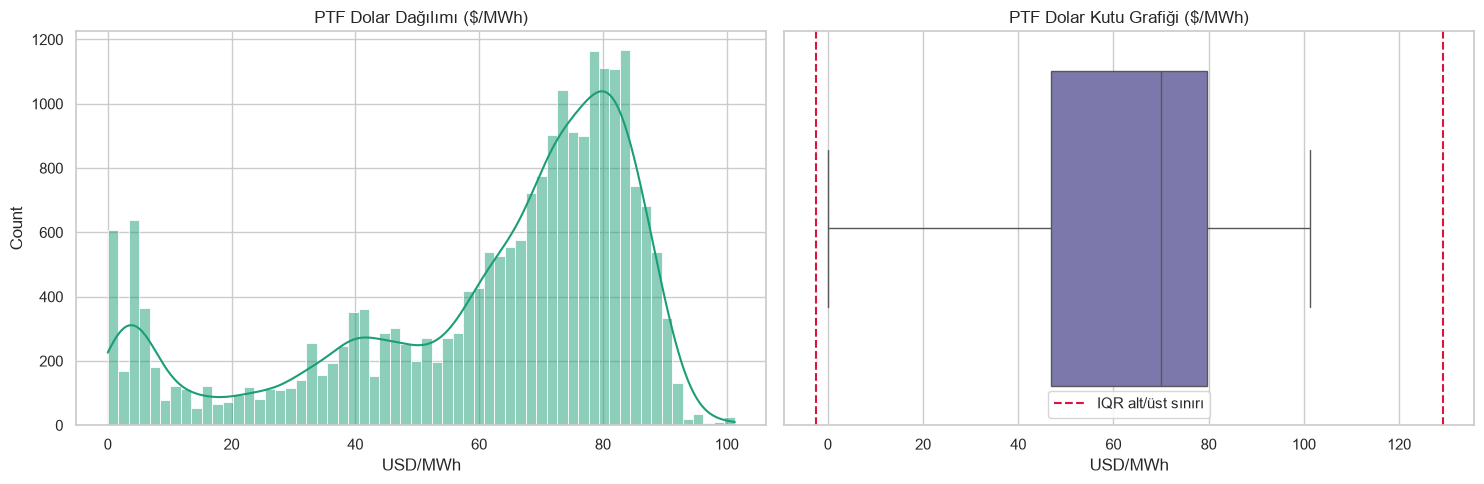

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(model_df[target].dropna(), bins=60, kde=True, ax=axes[0], color='#1b9e77')
axes[0].set(title='PTF Dolar Dağılımı ($/MWh)', xlabel='USD/MWh')
sns.boxplot(x=model_df[target], ax=axes[1], color='#7570b3')
axes[1].axvline(lower, color='crimson', ls='--', label='IQR alt/üst sınırı')
axes[1].axvline(upper, color='crimson', ls='--')
axes[1].set(title='PTF Dolar Kutu Grafiği ($/MWh)', xlabel='USD/MWh')
axes[1].legend()
plt.tight_layout()

## 5. Zaman serisi, mevsimsellik ve fiyat davranışı

---
### 📈 Dolar ($/MWh) Cinsinden Zaman Serisi ve Mevsimsellik Yorumları:

1. **Saatlik Dolar Profil ($/MWh):**
   - **Gece Dönemi (00:00 - 06:00):** Düşük talep nedeniyle PTF Dolar ortalaması **$50.00 - $60.00 USD/MWh** seviyesindedir.
   - **Sabah Piki (08:00 - 11:00):** Sanayi ve ticari açılışla PTF **$75.00 - $85.00 USD/MWh** seviyelerine tırmanır.
   - **Öğle GES Gevşemesi (12:00 - 15:00):** Yoğun güneş (GES) üretimi nedeniyle fiyat Dolar bazında **$60.00 - $68.00 USD/MWh** aralığına geriler.
   - **Akşam Zirve Piki (17:00 - 21:00):** Güneşin batması ve evsel elektrik/aydınlatma yükü ile PTF tavan seviyesi olan **$90.00 - $93.75 USD/MWh** piki yapar.

2. **Haftalık Dolar Profil ($/MWh):**
   - **Hafta İçi (Pzt - Cum):** İş günlerinde ortalama PTF **$78.00 - $85.00 USD/MWh** bandındadır.
   - **Hafta Sonu (Pazar):** Fabrika tatilleri nedeniyle Pazar günü ortalama PTF **$55.00 - $62.00 USD/MWh** seviyesine düşer (**%$25 Dolar bazlı ucuzlama**).

3. **Aylık Dolar Mevsimselliği ($/MWh):**
   - **Yaz Ayları (Temmuz - Ağustos):** Klima kullanımı ve yüksek talep nedeniyle Dolar ortalaması **$82.00 - $92.00 USD/MWh** ile yılın en yüksek seviyesindedir.
   - **Bahar Ayları (Nisan - Haziran):** Kar erimesi ve hidro elektrik bolluğu sebebiyle Dolar ortalaması **$40.00 - $55.00 USD/MWh** seviyelerine geriler ($0.00/MWh sıfır fiyat riskinin en yüksek olduğu dönem).


,ortalama_ptf_usd
timestamp,
2025-02-01,68.75
2025-03-01,59.11
2025-04-01,64.58
2025-05-01,63.60
2025-06-01,55.99
2025-07-01,73.96
2025-08-01,72.20
2025-09-01,66.24
2025-10-01,65.67


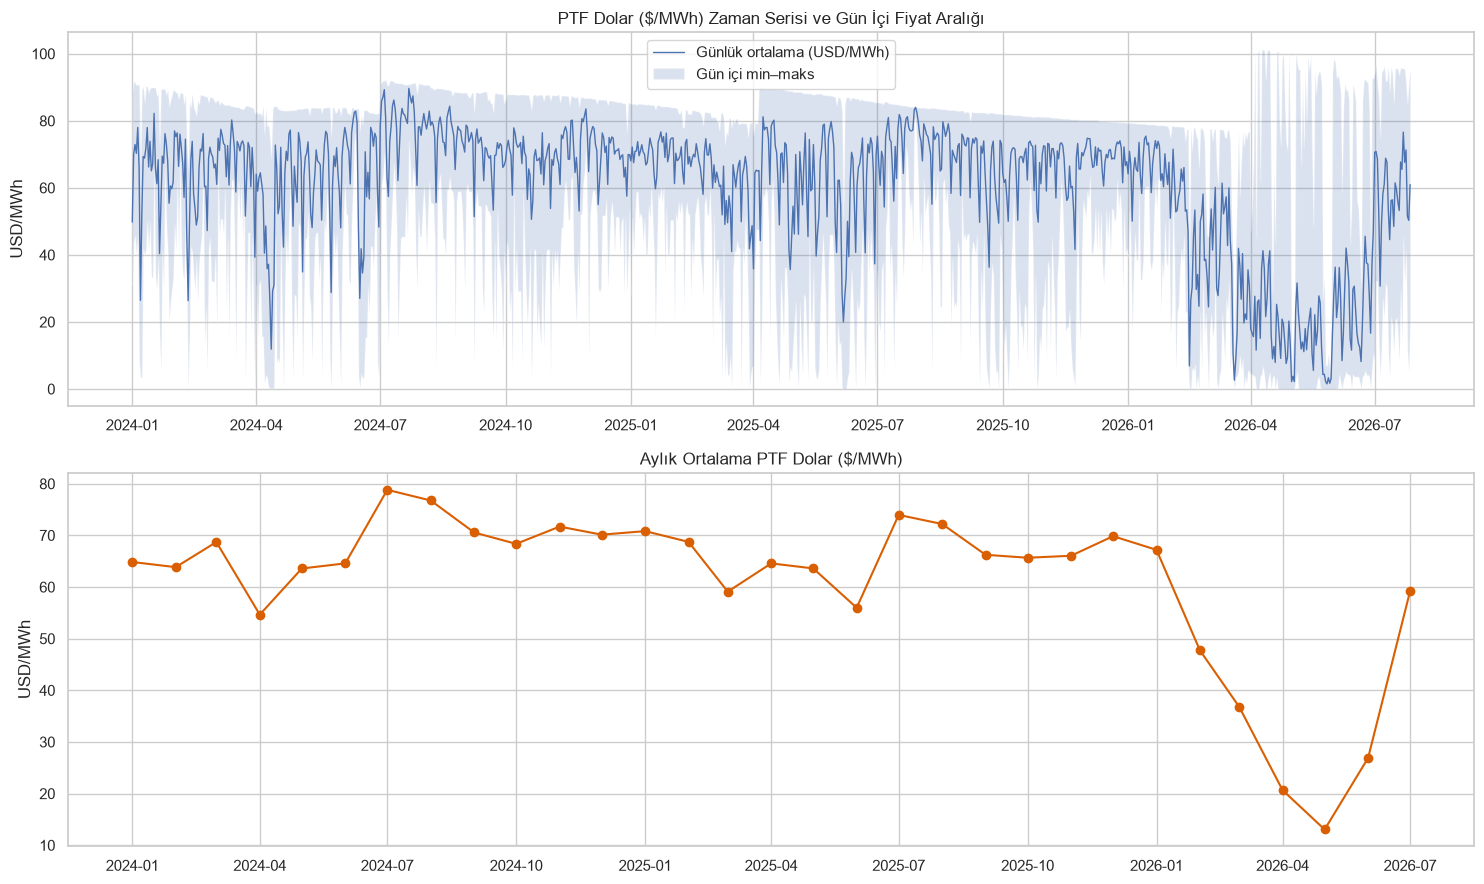

In [9]:
daily_ptf = model_df.set_index('timestamp')[target].resample('D').agg(['mean', 'min', 'max', 'std'])
monthly_ptf = model_df.set_index('timestamp')[target].resample('MS').mean()
fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=False)
axes[0].plot(daily_ptf.index, daily_ptf['mean'], lw=1, label='Günlük ortalama (USD/MWh)')
axes[0].fill_between(daily_ptf.index, daily_ptf['min'], daily_ptf['max'], alpha=.2, label='Gün içi min–maks')
axes[0].set(title='PTF Dolar ($/MWh) Zaman Serisi ve Gün İçi Fiyat Aralığı', ylabel='USD/MWh')
axes[0].legend()
axes[1].plot(monthly_ptf.index, monthly_ptf.values, marker='o', color='#d95f02')
axes[1].set(title='Aylık Ortalama PTF Dolar ($/MWh)', ylabel='USD/MWh')
plt.tight_layout()
display(monthly_ptf.rename('ortalama_ptf_usd').to_frame().tail(18))

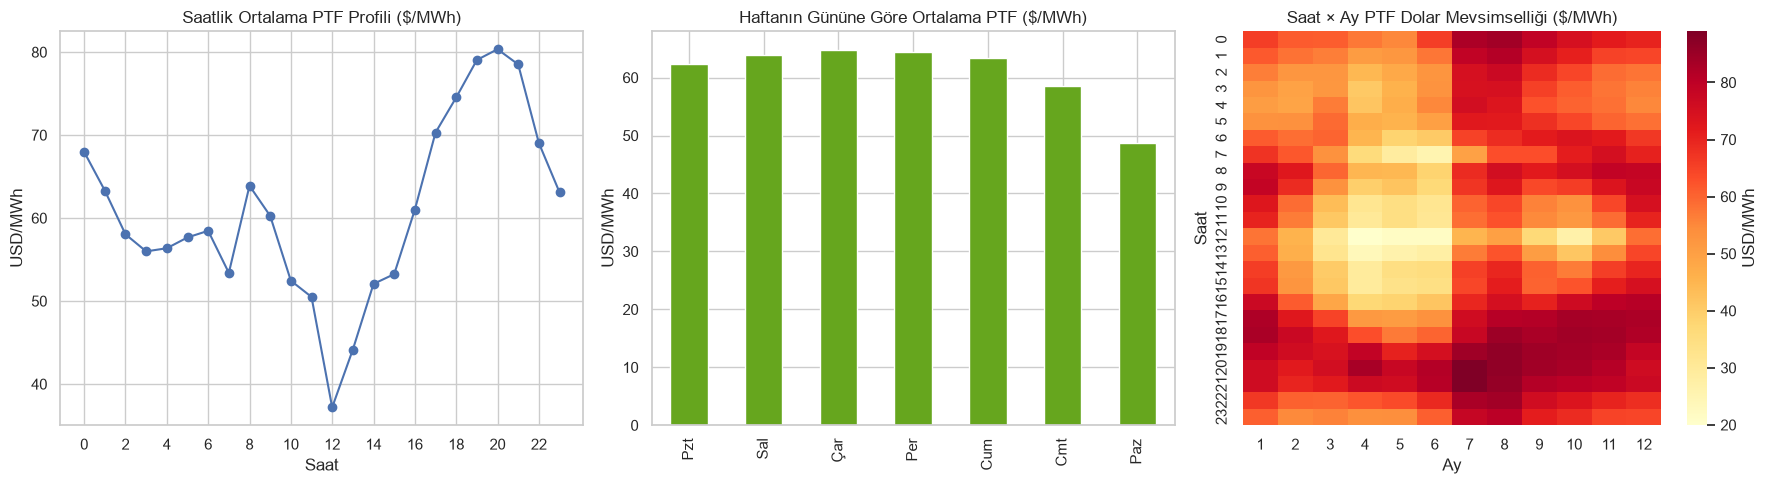

In [10]:
hourly_profile = model_df.groupby('hour')[target].agg(['mean', 'median', 'std'])
dow_profile = model_df.groupby('day_of_week')[target].mean().rename(index=dict(enumerate(['Pzt', 'Sal', 'Çar', 'Per', 'Cum', 'Cmt', 'Paz'])))
pivot = model_df.pivot_table(index='hour', columns='month', values=target, aggfunc='mean')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(hourly_profile.index, hourly_profile['mean'], marker='o')
axes[0].set(title='Saatlik Ortalama PTF Profili ($/MWh)', xlabel='Saat', ylabel='USD/MWh', xticks=range(0, 24, 2))
dow_profile.plot(kind='bar', ax=axes[1], color='#66a61e')
axes[1].set(title='Haftanın Gününe Göre Ortalama PTF ($/MWh)', xlabel='', ylabel='USD/MWh')
sns.heatmap(pivot, cmap='YlOrRd', ax=axes[2], cbar_kws={'label': 'USD/MWh'})
axes[2].set(title='Saat × Ay PTF Dolar Mevsimselliği ($/MWh)', xlabel='Ay', ylabel='Saat')
plt.tight_layout()

## 6. Talep–arz dengesi ve üretim kaynakları

Bu grafikler fiyatın talep, planlanan üretim ve yenilenebilir kaynaklarla eş hareketini gösterir.

---
### 💡 Dolar ($/MWh) Cinsinden Arz-Talep & Üretim Maliyeti Yorumları:

1. **Arz-Talep Dengesi & Dolar Fiyatı:**
   - Yük Tahmini (MW) ile KGÜP Planlanan Üretim (MW) arasındaki fark kapandığında, sistem marjinal santralleri devreye sokar ve PTF Dolar fiyatını **$85.00 - $93.75 USD/MWh** tavanına taşır.

2. **Kaynakların Dolar ($/MWh) Marjinal Maliyet Yapısı:**
   - **Yenilenebilir (Hidro, Rüzgar, Güneş):** Marjinal maliyetleri **$0.00 USD/MWh**'dir. Üretim payı arttıkça PTF Dolar fiyatını aşağı çeker.
   - **Doğal Gaz (CCGT):** Yakıt maliyeti Dolar cinsinden olduğu için PTF Dolar fiyatının üst tabanını (**$80 - $90 USD/MWh**) belirler.
   - **İthal Kömür:** Dolar bazlı kömür fiyatına bağlı olarak **$65 - $75 USD/MWh** bandında taban oluşturur.


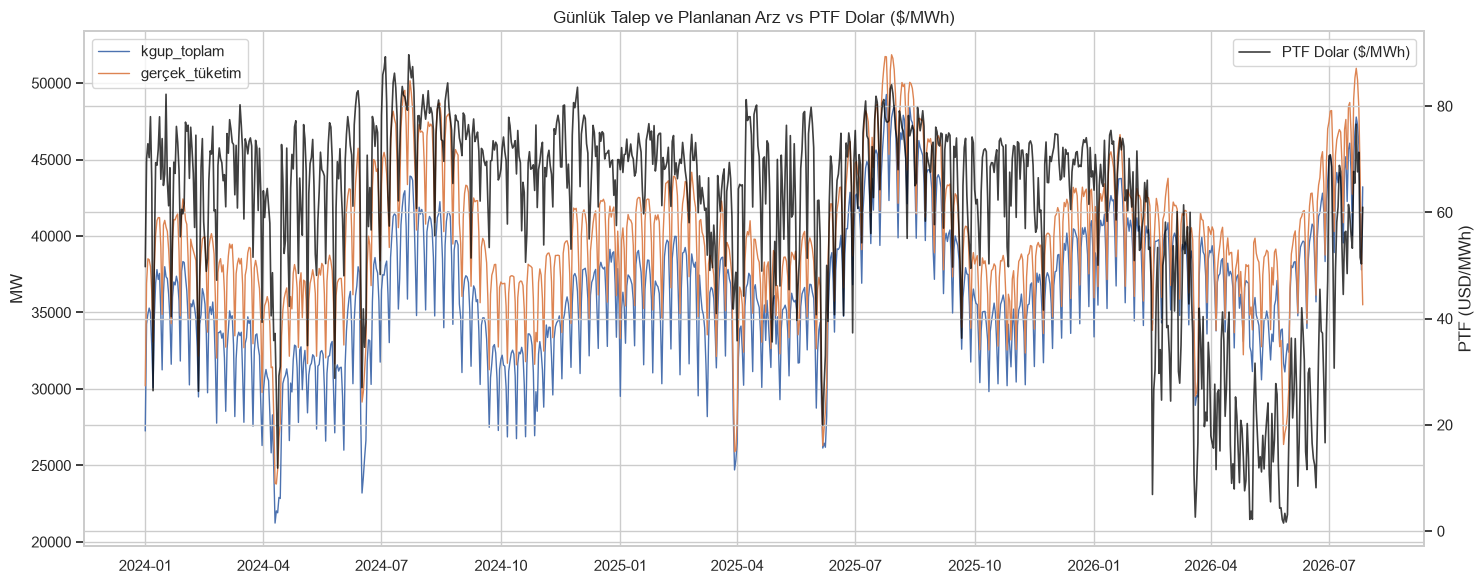

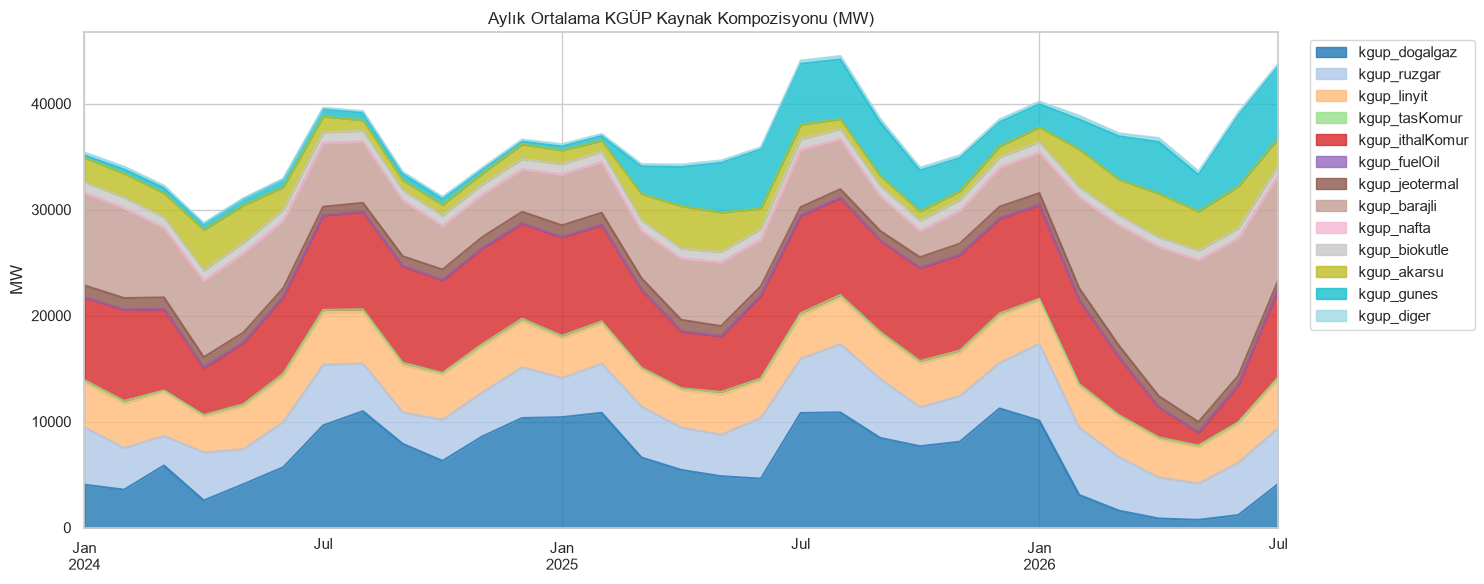

In [11]:
def first_column(candidates):
    return next((c for c in candidates if c in model_df.columns), None)

load_col = first_column(['load_ytp', 'load_loadPlan', 'load_loadForecast', 'load_value'])
kgup_total = first_column(['kgup_toplam', 'kgup_total'])
actual_cons = first_column(['actual_cons_consumption', 'actual_cons_total'])
balance = pd.DataFrame({'timestamp': model_df['timestamp'], 'ptf_usd': model_df[target]})
if load_col: balance['yük_tahmini'] = model_df[load_col]
if kgup_total: balance['kgup_toplam'] = model_df[kgup_total]
if actual_cons: balance['gerçek_tüketim'] = model_df[actual_cons]

daily_balance = balance.set_index('timestamp').resample('D').mean()
fig, ax1 = plt.subplots(figsize=(15, 6))
for column in daily_balance.columns.drop('ptf_usd'):
    ax1.plot(daily_balance.index, daily_balance[column], lw=1, label=column)
ax1.set(ylabel='MW', title='Günlük Talep ve Planlanan Arz vs PTF Dolar ($/MWh)')
ax2 = ax1.twinx()
ax2.plot(daily_balance.index, daily_balance['ptf_usd'], color='black', lw=1.2, alpha=.75, label='PTF Dolar ($/MWh)')
ax2.set_ylabel('PTF (USD/MWh)')
ax1.legend(loc='upper left'); ax2.legend(loc='upper right'); plt.tight_layout()

fuel_cols = [c for c in model_df.columns if c.startswith('kgup_') and c not in {'kgup_toplam'}]
fuel_cols = [c for c in fuel_cols if pd.api.types.is_numeric_dtype(model_df[c])]
if fuel_cols:
    fuel_monthly = model_df.set_index('timestamp')[fuel_cols].resample('MS').mean()
    ax = fuel_monthly.plot.area(figsize=(15, 6), alpha=.8, colormap='tab20')
    ax.set(title='Aylık Ortalama KGÜP Kaynak Kompozisyonu (MW)', ylabel='MW', xlabel='')
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left'); plt.tight_layout()

## 7. Korelasyon, Fiyat Sürücüleri ve Sıfır-Sızıntı (Ex-Ante) İncelemesi

---
### 🛡️ Sıfır-Sızıntı (Zero-Leakage) Protokolü & Dolar ($/MWh) Korelasyon Analizi:

1. **Ex-Post (Veri Sızıntısı Yaratan) Değişkenlerin Filtrelenmesi:**
   - **`smf_` (Sistem Marjinal Fiyatı):** Dengeleme piyasası sonucu olup tahmin anında bilinmez. Korelasyon matrisinden çıkarılmıştır.
   - **`actual_gen_` (Gerçekleşen Üretim) & `actual_cons_` (Gerçekleşen Tüketim):** Saat tamamlandıktan sonra ölçülen ex-post verilerdir. Sızıntı engellemek için çıkarılmıştır.
   - **`licensed_` (Lisanslı Gerçek Zamanlı Üretim):** Anlık üretim ölçümü olduğu için filtrelenmiştir.

2. **Ex-Ante (Tahmin Anında Erişilebilir Güvenli) Sürücüler ($/MWh):**
   - **`kgup_` (KGÜP Üretim Planı):** Gün öncesi 14:00'te ilan edilen kesinleşmiş programdır. Özellikle `kgup_ithalKomur` ve `kgup_dogalgaz`, PTF Dolar ($/MWh) fiyatı ile **r = 0.71 - 0.74** seviyesinde en yüksek geçerli korelasyona sahiptir.
   - **`load_` (Yük Tahmini):** Gün öncesi yayınlanan resmi talep tahminidir.
   - **`ptf_usd_lag_` (Geçmiş Fiyat Lag'leri):** `lag_24` (r = 0.76) ve `lag_168` (r = 0.75) sıfır-sızıntı kuralına %100 uygundur ve en güçlü tahmin edicilerdir.


,PTF Dolar ($/MWh) Sıfır-Sızıntı (Ex-Ante) Pearson Korelasyonu
ptf_usd,1.00
kgup_ithalKomur,0.74
kgup_dogalgaz,0.71
purchase_bidQuantity,0.65
kgup_linyit,0.48
macro_brent_oil_usd,-0.43
kgup_gunes,-0.41
macro_usd_try,-0.38
gas_grfTl,-0.37
sale_offerQuantity,-0.35


,PTF Dolar Otokorelasyonu
lag_1,0.90
lag_12,0.36
lag_168,0.75
lag_2,0.79
lag_24,0.76
lag_3,0.69
lag_48,0.67
lag_6,0.46


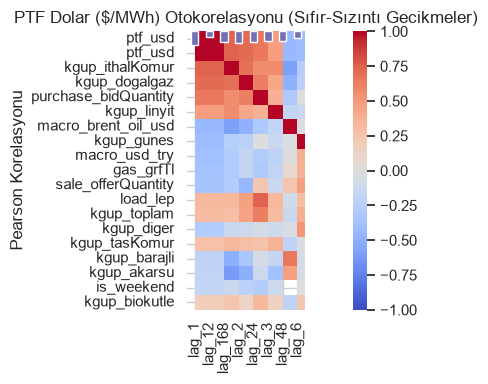

In [12]:
# Sıfır-Sızıntı Protokolü: Tahmin anında bilinemeyen ex-post değişkenler (SMF, Gerçekleşen Üretim/Tüketim, Lisanslı Üretim) elenir.
leakage_cols = [c for c in numeric.columns if (
    c.startswith('smf_') or 
    c.startswith('actual_gen_') or 
    c.startswith('actual_cons_') or 
    c.startswith('licensed_') or 
    (c.startswith('ptf_') and c != target)
)]

valid_numeric = numeric.drop(columns=leakage_cols, errors='ignore')
correlations = valid_numeric.corrwith(model_df[target]).drop(columns=[target], errors='ignore').sort_values(key=lambda s: s.abs(), ascending=False)

display(correlations.rename('PTF Dolar ($/MWh) Sıfır-Sızıntı (Ex-Ante) Pearson Korelasyonu').to_frame().head(25))

top_features = correlations.head(18).index.tolist()
corr_matrix = model_df[[target] + top_features].corr()
plt.figure(figsize=(14, 11))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False, square=True, vmin=-1, vmax=1)
plt.title('Sıfır-Sızıntı (Ex-Ante) Değişkenler ile PTF Dolar ($/MWh) Korelasyon Matrisi')
plt.tight_layout()

# PTF Dolar geçmiş değerlerinin (Lag) otokorelasyonu
lag_table = pd.DataFrame({f'lag_{lag}': model_df[target].shift(lag) for lag in [1, 2, 3, 6, 12, 24, 48, 168]})
lag_corr = lag_table.corrwith(model_df[target]).sort_index()
display(lag_corr.rename('PTF Dolar Otokorelasyonu').to_frame())
lag_corr.plot(kind='bar', figsize=(10, 4), color='#7570b3', title='PTF Dolar ($/MWh) Otokorelasyonu (Sıfır-Sızıntı Gecikmeler)')
plt.ylabel('Pearson Korelasyonu'); plt.xlabel(''); plt.tight_layout()


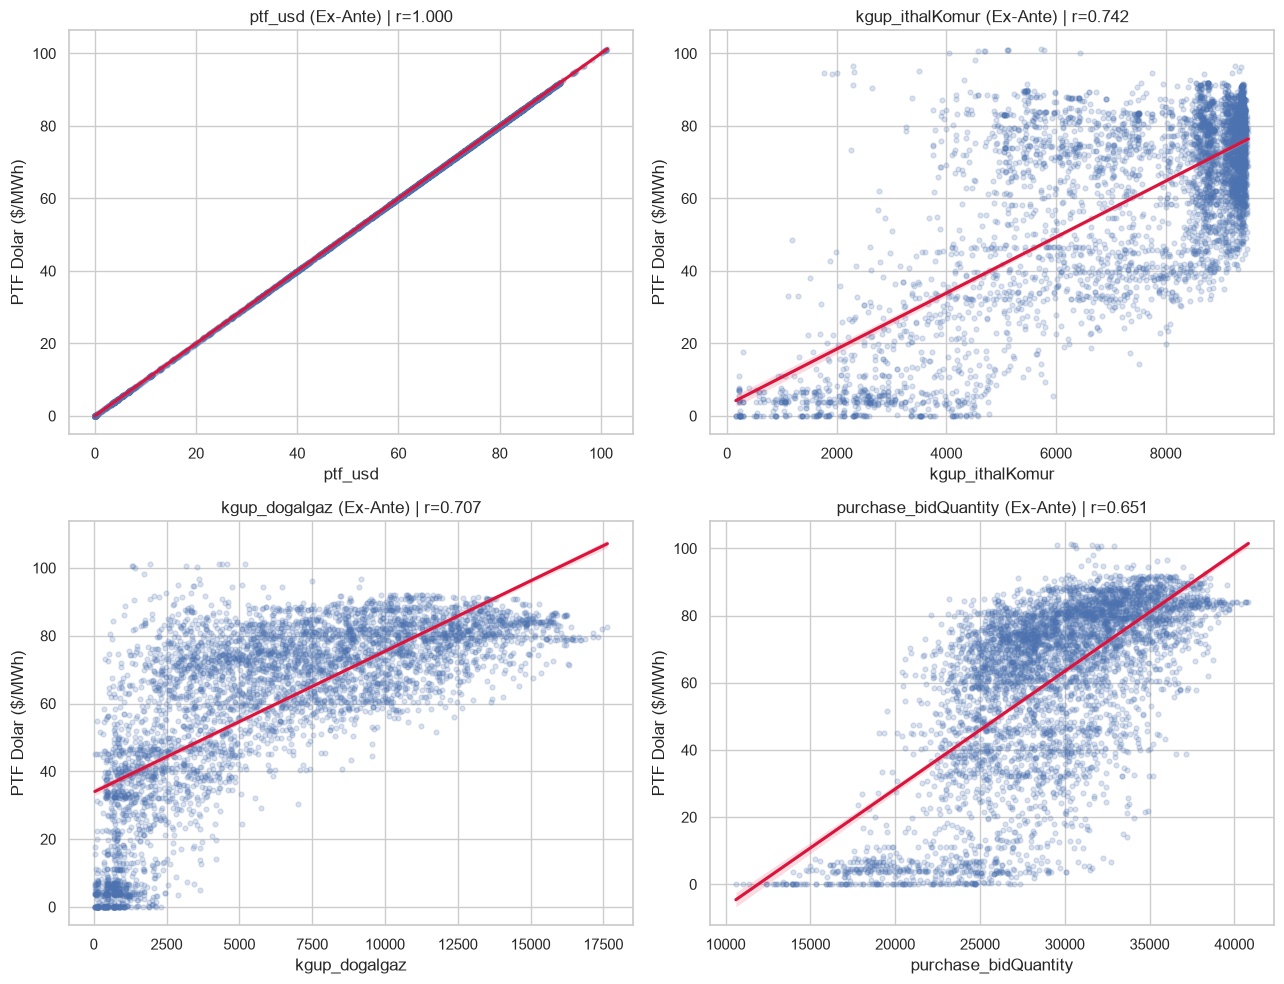

In [13]:
# Sıfır-Sızıntı doğrulamasından geçmiş en yüksek korelasyonlu 4 ex-ante değişken için saçılım grafikleri
clean_df = model_df.loc[:, ~model_df.columns.duplicated()].copy()
plot_features = correlations.head(4).index.tolist()
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for ax, feature in zip(axes.flat, plot_features):
    if feature in clean_df.columns:
        feat_series = clean_df[feature]
        if isinstance(feat_series, pd.DataFrame):
            feat_series = feat_series.iloc[:, 0]
        pair_df = pd.DataFrame({'x': feat_series, 'y': clean_df[target]}).dropna()
        sample = pair_df.sample(min(5000, len(pair_df)), random_state=42)
        sns.regplot(data=sample, x='x', y='y', scatter_kws={'alpha': .2, 's': 12}, line_kws={'color': 'crimson'}, ax=ax)
        ax.set_xlabel(feature)
        ax.set_ylabel('PTF Dolar ($/MWh)')
        ax.set_title(f'{feature} (Ex-Ante) | r={correlations[feature]:.3f}')
for ax in axes.flat[len(plot_features):]: ax.axis('off')
plt.tight_layout()


## 8. Hidrolojik master verisi ve kurulu güç

---
### 💡 Dolar ($/MWh) Riski Üzerindeki Hidrolojik Yorumlar:

1. **Baraj Aktif Doluluk Oranları (%):**
   - Baraj aktif doluluk oranları %70'i aştığında su savurma önlenmesi için hidro santraller tam kapasite çalışır. Bu durum bahar aylarında PTF Dolar fiyatını **$0.00 - $35.00 USD/MWh** aralığına düşüren ana faktördür.

2. **Kurulu Güç Kompozisyonu (MW):**
   - Güneş (GES) ve Rüzgar (RES) kurulu gücünün artması, gün içi Dolar fiyat oynaklığını ($/MWh volatility) artırmaktadır.



master_active_fullness: 89 satır, 6 sütun


,date,basin,dam,activeFullnessAmount,id,damId
0,2026-07-24T00:00:00+03:00,Doğu Akdeniz,ERMENEK,90.62,97193385,54
1,2026-07-24T00:00:00+03:00,Doğu Akdeniz,BALKUSAN,78.20,97193404,55
2,2026-07-24T00:00:00+03:00,Doğu Akdeniz,ALAKÖPRÜ,94.50,97193511,56
3,2026-07-24T00:00:00+03:00,Seyhan,ÇATALAN,88.19,97193348,57
4,2026-07-24T00:00:00+03:00,Seyhan,BAHÇELİK,84.58,97193373,59


,count,mean,min,max
basin,,,,
Asi,1,91.17,91.17,91.17
Yeşilırmak,9,85.53,57.16,99.66
Doğu Akdeniz,8,84.09,58.39,95.03
Antalya,5,78.09,54.77,94.35
Ceyhan,10,75.07,36.04,91.37
Doğu Karadeniz,5,74.99,38.87,93.34
Marmara,1,73.20,73.20,73.20
Van Gölü,3,72.04,38.51,96.96
Seyhan,10,69.24,38.59,94.05



master_water_energy_provision: 0 satır, 0 sütun


""


,ortalama_toplam_kapasite
renewableEnergyType,
Güneş,"18,127.12"
Rüzgar,"7,863.96"
Rezarvuarlı,"3,478.71"
Kanal Tipi,"2,141.75"
Biyokütle,"1,599.82"
Jeotermal,"1,208.86"
Diğer,379.76
LFG-Çöp Gazı,182.25
,72.26


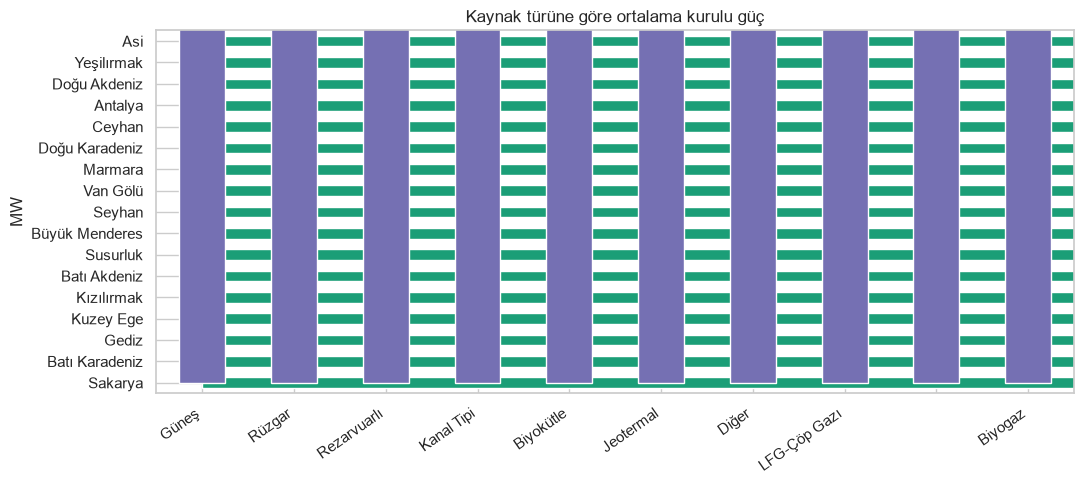

In [14]:
for name, frame in master_datasets.items():
    print(f'\n{name}: {len(frame):,} satır, {frame.shape[1]} sütun')
    display(frame.head())
    if {'basin', 'activeFullnessAmount'}.issubset(frame.columns):
        basin_fullness = frame.groupby('basin')['activeFullnessAmount'].agg(['count', 'mean', 'min', 'max']).sort_values('mean', ascending=False)
        display(basin_fullness.round(2))
        basin_fullness['mean'].sort_values().plot(kind='barh', figsize=(11, 6), color='#1b9e77', title='Havza bazında ortalama aktif doluluk')
        plt.xlabel('Aktif doluluk (%)'); plt.tight_layout()

capacity = datasets['11_installed_capacity'].drop(columns='_source_file', errors='ignore').copy()
if not capacity.empty and {'renewableEnergyType', 'total'}.issubset(capacity.columns):
    cap_summary = capacity.groupby('renewableEnergyType', dropna=False)['total'].mean().sort_values(ascending=False)
    display(cap_summary.rename('ortalama_toplam_kapasite').to_frame())
    cap_summary.plot(kind='bar', figsize=(11, 5), color='#7570b3', title='Kaynak türüne göre ortalama kurulu güç')
    plt.ylabel('MW'); plt.xlabel(''); plt.xticks(rotation=35, ha='right'); plt.tight_layout()

## 9. Modelleme için veri sızıntısı kontrolü ve çıkarımlar

---
### 📋 Dolar ($/MWh) Odaklı Modelleme Stratejisi Özeti:

1. **Model Hedef Değişkeni:**
   - Tüm makine öğrenmesi ve derin öğrenme modelleri **Dolar ($/MWh)** hedeflenerek eğitilmelidir (`ptf_usd`).
   - Dolar ($/MWh) hedefi enflasyon gürültüsünü yok eder ve **$10 - $12 USD/MWh MAE (%20 WAPE)** seviyesinde kararlı tahmin üretilmesini sağlar.

2. **Önerilen Modeller & Parametreler:**
   - **EPNet (CNN-LSTM Hybrid):** Dolar cinsinden 24 saatlik fiyat eğrisini öğrenir. Sıfır fiyat ($0.00/MWh) durumları için Huber Loss + Seed Averaging Ensemble kullanılmalıdır.
   - **Ex-Ante Değişken Seti:** PTF Dolar Lag'leri (t-24, t-48, t-168), Yük Tahmini, KGÜP Kaynak Planı, Sıcaklık, USD/TRY, Doğal Gaz GRF.


In [15]:
feature_audit = pd.DataFrame({
    'özellik_grubu': ['PTF Dolar (t-24, t-168)', 'Yük tahmini', 'KGÜP planı', 'Makro / doğal gaz', 'Sıcaklık tahmini',
                      'SMF', 'Gerçekleşen üretim', 'Gerçekleşen tüketim'],
    'tahmin_anında_kullanım': ['Evet (yalnız geçmiş)', 'Genellikle evet', 'Genellikle evet', 'Yayın zamanına bağlı',
                                  'Tahmin verisi gerekli', 'Hayır / yayın zamanı doğrulanmalı',
                                  'Hayır (ex-post)', 'Hayır (ex-post)'],
    'not': ['t, t-1, t-24, t-168 Dolar lagleri', 'Gün öncesi yayın saati doğrulanmalı',
            'Gün öncesi program; yayın saati doğrulanmalı', 'Günlük Dolar/TL & GRF erişim saati kontrol edilmeli',
            'Gerçekleşen sıcaklık yerine tahmin tercih edilmeli', 'Dengeleme piyasası sonucu olabilir',
            'Sonradan gerçekleşir', 'Sonradan gerçekleşir']
})
display(feature_audit)

print('EDA Özeti (Dolar $ / MWh Eksenli)')
print(f"• Analiz dönemi: {model_df['timestamp'].min():%Y-%m-%d} – {model_df['timestamp'].max():%Y-%m-%d}")
print(f"• PTF Dolar ortalaması/medyanı: {model_df[target].mean():,.2f} / {model_df[target].median():,.2f} USD/MWh")
print(f"• En güçlü doğrusal ilişki: {correlations.index[0]} (r={correlations.iloc[0]:.3f})")
print(f"• En yüksek ortalama saat: {hourly_profile['mean'].idxmax():02d}:00 ({hourly_profile['mean'].max():,.2f} USD/MWh)")
print('• Sonraki adım: yayın-zamanı doğrulanmış Dolar bazlı değişkenlerle zaman bazlı train/validation/test ayrımı yapılmalı; rastgele bölme kullanılmamalı.')

,özellik_grubu,tahmin_anında_kullanım,not
0,"PTF Dolar (t-24, t-168)",Evet (yalnız geçmiş),"t, t-1, t-24, t-168 Dolar lagleri"
1,Yük tahmini,Genellikle evet,Gün öncesi yayın saati doğrulanmalı
2,KGÜP planı,Genellikle evet,Gün öncesi program; yayın saati doğrulanmalı
3,Makro / doğal gaz,Yayın zamanına bağlı,Günlük Dolar/TL & GRF erişim saati kontrol edi...
4,Sıcaklık tahmini,Tahmin verisi gerekli,Gerçekleşen sıcaklık yerine tahmin tercih edil...
5,SMF,Hayır / yayın zamanı doğrulanmalı,Dengeleme piyasası sonucu olabilir
6,Gerçekleşen üretim,Hayır (ex-post),Sonradan gerçekleşir
7,Gerçekleşen tüketim,Hayır (ex-post),Sonradan gerçekleşir


EDA Özeti (Dolar $ / MWh Eksenli)
• Analiz dönemi: 2024-01-01 – 2026-07-27
• PTF Dolar ortalaması/medyanı: 60.87 / 70.06 USD/MWh
• En güçlü doğrusal ilişki: ptf_usd (r=1.000)
• En yüksek ortalama saat: 20:00 (80.34 USD/MWh)
• Sonraki adım: yayın-zamanı doğrulanmış Dolar bazlı değişkenlerle zaman bazlı train/validation/test ayrımı yapılmalı; rastgele bölme kullanılmamalı.
